In [1]:
import torch

def convert_tensor_types(input_tensor):
# 定义所有需要转换的张量类型及其后缀形式
    dtype_conversions = {
    '32位浮点数':(torch.float32,'FloatTensor'),
    '64位浮点数':(torch.float64,'DoubleTensor'),
    '16位浮点数':(torch.float16,'HalfTensor'),
    '8位无符号整数':(torch.uint8,'ByteTensor'),
    '8位有符号整数':(torch.int8,'CharTensor'),
    '16位有符号整数':(torch.int16,'ShortTensor'),
    '32位有符号整数':(torch.int32,'IntTensor'),
    '64位有符号整数':(torch.int64,'LongTensor'),
    '布尔值':(torch.bool,'BoolTensor')

    }

    print(f"原始张量:{input_tensor}")
    print(f"原始数据类型:{input_tensor.dtype}\n")

    for name, (dtype, suffix) in dtype_conversions.items ():
        converted_tensor = input_tensor.to(dtype)
        print(f"转换为{name}({suffix}):")
        print(converted_tensor)
        print(f"转换后的数据类型:{converted_tensor.dtype}\n")

In [2]:
import torch
x = torch.arange(6)
x

tensor([0, 1, 2, 3, 4, 5])

In [3]:
x.shape

torch.Size([6])

In [4]:
x.numel() #处理：返回张量中的元素数量

6

In [5]:
#创建一维张量
x1 = torch.tensor([1, 2, 3, 4, 5])
#numel()返回张量中的元素数量
elem_count = x1.numel()
print(f'一维张量: {x1}, 元素数量: {elem_count}')


一维张量: tensor([1, 2, 3, 4, 5]), 元素数量: 5


In [6]:
x2 = torch.randn(2, 3, 4) #创建一个2x3x4的三维张量,2, 3, 4分别为深度、高度、宽度
elem_count_2 = x2.numel()
print(f'三维张量: {x2}, 元素数量: {elem_count_2}')

三维张量: tensor([[[ 0.1519, -0.4747, -1.5474, -0.3074],
         [ 0.0598, -0.6689, -1.8582,  1.0596],
         [ 0.4462, -1.1722,  1.6159,  1.7737]],

        [[-0.6441, -1.5237,  1.2146,  0.0550],
         [-0.5718, -4.3738,  0.5736, -1.0334],
         [ 0.4607, -2.5816, -1.2643,  1.2141]]]), 元素数量: 24


In [7]:
#空张量的numel
x3 = torch.tensor([])
elem_count_3 = x3.numel()
print(f'空张量: {x3}, 元素数量: {elem_count_3}')

空张量: tensor([]), 元素数量: 0


In [8]:
X = x.reshape(3, 2)
X

tensor([[0, 1],
        [2, 3],
        [4, 5]])

开始训练线性回归模型...
初始参数：b0 = 0.0130, b1 = 1.4535
Epoch [100/1000], Loss: 0.2516, b0: 0.1904, b1: 0.5411
Epoch [200/1000], Loss: 0.2181, b0: 0.3684, b1: 0.5138
Epoch [300/1000], Loss: 0.2070, b0: 0.4704, b1: 0.4981
Epoch [400/1000], Loss: 0.2034, b0: 0.5289, b1: 0.4891
Epoch [500/1000], Loss: 0.2022, b0: 0.5625, b1: 0.4839
Epoch [600/1000], Loss: 0.2018, b0: 0.5817, b1: 0.4810
Epoch [700/1000], Loss: 0.2017, b0: 0.5927, b1: 0.4793
Epoch [800/1000], Loss: 0.2017, b0: 0.5991, b1: 0.4783
Epoch [900/1000], Loss: 0.2017, b0: 0.6027, b1: 0.4778
Epoch [1000/1000], Loss: 0.2016, b0: 0.6048, b1: 0.4774
训练完成！
最终参数：b0 = 0.6048, b1 = 0.4774
拟合方程：y = 0.6048 + 0.4774 * x
可视化图像已保存到输出目录。


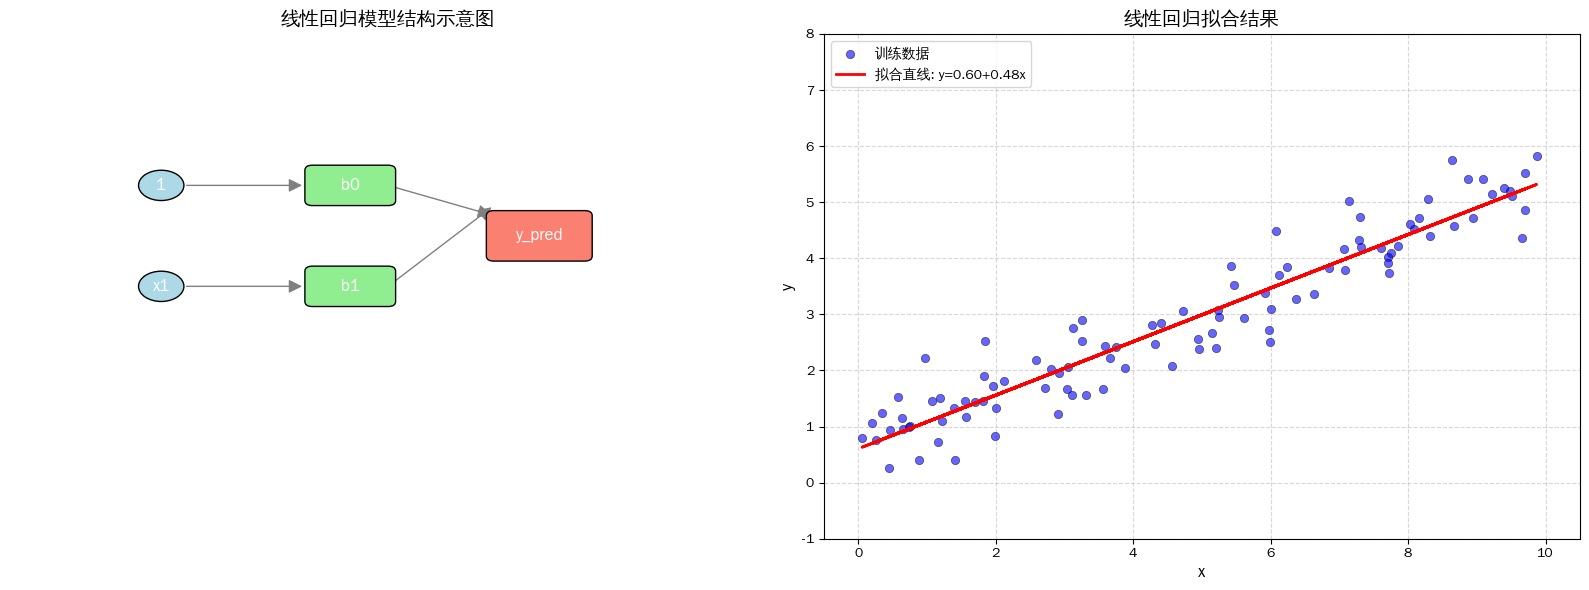

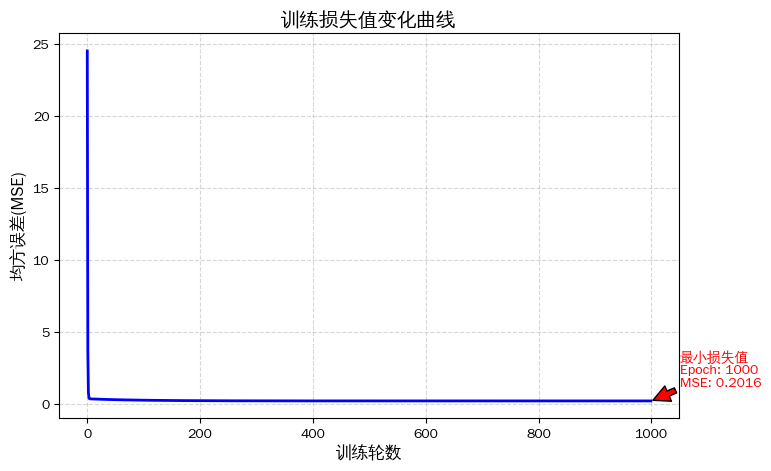


所有文件已保存到目录: /workspaces/coding/deepLearning/output


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch 
import warnings

# ================配置部分==================
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方块的问题
# plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'DejaVu Sans']
# plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于显示中文标签
# plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方块的问题
warnings.filterwarnings("ignore")  # 忽略警告信息
np.random.seed(42)  # 设置随机种子，确保结果可复现

n_samples = 100  # 样本数量
x = np.random.uniform(0, 10, n_samples)  # 在0到10之间均匀分布生成100个样本点
noise = np.random.normal(0, 0.5, n_samples)  # 生成噪声

# 生成目标变量y，真实关系为y = 0.5 + 0.5 * x + 噪声
y = 0.5 + 0.5 * x + noise

# =============数据预处理=============
X_train = x.reshape(-1, 1)  # 将输入特征x转换为二维数组
y_train = y.reshape(-1, 1)  # 将目标变量y转换为二维数组

# =============神经网络参数初始化=============
b0 = np.random.randn()  # 偏置项（截距）
b1 = np.random.randn()  # 权重项（斜率）

# ========定义神经网络函数========
def forward(x, b0, b1):
    """计算线性模型的预测值"""
    return b0 + b1 * x

def compute_loss(y_pred, y_true):
    """计算均方误差 (MSE)"""
    # 修复：原代码使用了 torch.mean，这里是 numpy 环境，应使用 np.mean
    return np.mean((y_pred - y_true) ** 2)

# =========训练超参数设置=========
learning_rate = 0.01
num_epochs = 1000
loss_history = []

# ==================开始训练====================
print("=" * 50)
print("开始训练线性回归模型...")
print("=" * 50)
print(f"初始参数：b0 = {b0:.4f}, b1 = {b1:.4f}")
print("=" * 50)

for epoch in range(num_epochs):
    # 1. 前向传播
    y_pred = forward(X_train, b0, b1)
    
    # 2. 计算损失值
    loss = compute_loss(y_pred, y_train)
    loss_history.append(loss)
    
    # 修复：移除 loss.backward()，因为这是 PyTorch 的方法，Numpy 需要手动计算梯度
    
    # 3. 反向传播计算梯度
    error = y_pred - y_train
    
    # 计算损失函数对 b0 的偏导数
    grad_b0 = 2 * np.mean(error)
    
    # 计算损失函数对 b1 的偏导数
    grad_b1 = 2 * np.mean(error * X_train)
    
    # 4. 参数更新：梯度下降
    b0 -= learning_rate * grad_b0
    b1 -= learning_rate * grad_b1
    
    # =============打印训练过程中的信息=============
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss:.4f}, b0: {b0:.4f}, b1: {b1:.4f}")

# ============训练结束===========
print("=" * 50)
print("训练完成！")
print(f"最终参数：b0 = {b0:.4f}, b1 = {b1:.4f}")
print(f"拟合方程：y = {b0:.4f} + {b1:.4f} * x")
print("=" * 50)

# ===========模型预测==========
predicted = forward(X_train, b0, b1)

# ==========创建输出目录===========
output_dir = "output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# =========== 创建可视化 ========
fig = plt.figure(figsize=(16, 6))

# 子图1：线性回归模型结构示意图
ax1 = plt.subplot(1, 2, 1)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)
ax1.axis('off')  # 关闭坐标轴显示

# ============控制输入层节点===========
input_y_pos = [7, 5]
input_labels = ['1', 'x1']
input_nodes = []

for i, (y_pos, label) in enumerate(zip(input_y_pos, input_labels)):
    # 创建圆形补丁
    circle = plt.Circle((2, y_pos), 0.3, color='lightblue', ec='black', zorder=2)
    # 修复：原代码这里写的是 ax2.add_patch，此时 ax2 未定义，应为 ax1
    ax1.add_patch(circle)
    ax1.text(2, y_pos, label, fontsize=12, ha='center', va='center', zorder=4, color='white')
    # 修复：append 只能接受一个参数，需要加括号变成元组
    input_nodes.append((2, y_pos))

# ===========绘制参数节点===========
param_pos = [(4.5, 7, 'b0'), (4.5, 5, 'b1')]
param_nodes = []

for x_pos, y_pos, label in param_pos:
    ellipse = FancyBboxPatch((x_pos - 0.5, y_pos - 0.3), 1, 0.6, boxstyle="round,pad=0.1", 
                             fc="lightgreen", ec="black", zorder=2)
    ax1.add_patch(ellipse)
    ax1.text(x_pos, y_pos, label, fontsize=12, ha='center', va='center', zorder=4, color='white', weight='bold')
    param_nodes.append((x_pos, y_pos))

# ===========控制输出节点=============
output_x, output_y = 7, 6
output_box = FancyBboxPatch((output_x - 0.6, output_y - 0.4), 1.2, 0.8, 
                            boxstyle="round,pad=0.1", fc="salmon", ec="black", zorder=2)
ax1.add_patch(output_box)
ax1.text(output_x, output_y, 'y_pred', fontsize=12, ha='center', va='center', zorder=4, color='white', weight='bold')

# ===========绘制连接线=============
# 修复：原代码使用 FancyBboxPatch 绘制箭头是错误的，应使用 FancyArrowPatch
# 从输入节点到参数
arrow1 = FancyArrowPatch((2.3, 7), (3.9, 7), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow1)

arrow2 = FancyArrowPatch((2.3, 5), (3.9, 5), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow2)

# 从参数到输出
arrow3 = FancyArrowPatch((5.0, 7), (6.4, 6.4), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow3)

arrow4 = FancyArrowPatch((5.0, 5), (6.4, 6.6), arrowstyle='-|>', mutation_scale=20, color='gray', zorder=1)
ax1.add_patch(arrow4)

ax1.set_title('线性回归模型结构示意图', fontsize=14)

# 子图2：训练数据与拟合直线
ax2 = plt.subplot(1, 2, 2)
ax2.scatter(x, y, alpha=0.6, color='blue', edgecolor='k', linewidth=0.5, zorder=3, label='训练数据')

# ============绘制拟合曲线========
# 修复：原代码 label 参数重复了，这里合并
ax2.plot(x, predicted, color='red', linewidth=2, zorder=4, label=f'拟合直线: y={b0:.2f}+{b1:.2f}x')

ax2.grid(True, linestyle='--', alpha=0.5, zorder=1)
ax2.set_xlabel('x', fontsize=12, weight='bold')
ax2.set_ylabel('y', fontsize=12, weight='bold')
ax2.set_title('线性回归拟合结果', fontsize=14)
ax2.legend(fontsize=10, loc='upper left')
ax2.set_xlim(-0.5, 10.5)
ax2.set_ylim(-1, 8)

plt.tight_layout()
# 保存图像
# plt.savefig(os.path.join(output_dir, 'linear_regression_result.png'), dpi=300)
print("可视化图像已保存到输出目录。")

# ===============绘制训练损失函数===============
plt.figure(figsize=(8, 5))
plt.plot(loss_history, color='blue', linewidth=2)
plt.xlabel('训练轮数', fontsize=12, weight='bold')
plt.ylabel('均方误差(MSE)', fontsize=12, weight='bold')
plt.title('训练损失值变化曲线', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# ===================添加最小的损失值标记=================
min_loss = min(loss_history)
min_epoch = loss_history.index(min_loss) + 1

plt.annotate(f'最小损失值\nEpoch: {min_epoch}\nMSE: {min_loss:.4f}',
             xy=(min_epoch, min_loss),
             xytext=(min_epoch + 50, min_loss + 1),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=10, color='red', weight='bold')

# plt.savefig(os.path.join(output_dir, 'training_loss_curve.png'), dpi=300)
plt.show()

# ================打印最终信息=============
print(f"\n所有文件已保存到目录: {os.path.abspath(output_dir)}")

In [ ]:
#体育比赛预测网络系统
#功能：基于历史数据预测比赛结果
#使用二分类神经网络， 输出胜利概率
#====================导入必要的库====================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, FancyArrowPatch, Rectangle
import os
import warnings
from sklearn.base import accuracy_score

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示为方
warnings.filterwarnings("ignore")  # 忽略警告信息

#==============神经网络定义=============
class SportPredictor:
    """
    体育比赛预测神经网络系统
    功能：基于历史数据预测比赛结果
    """
    def __init__(self, n_features=5, learning_rate=0.01):
        """初始化预测器，设置网络的基本参数
        参数说明：
        n_features: 输入特征的数量
        learning_rate: 学习率
        """
        #保存特征数量，后续用于权重的初始化和计算
        self.n_features = n_features  # 输入特征数量
        #保存学习率，用于梯度下降时的参数更新
        self.learning_rate = learning_rate  # 学习率
        # 初始化权重和偏置
        self.weights = np.random.randn(n_features) * 0.01  # 小随机数初始化权重
        self.bias = 0.0  # 偏置初始化为0
        self.loss_history = []  # 用于记录训练过程中的损失值
    
    def sigmoid(self, x):
        """
        Sigmoid激活函数，将输入映射到0-1之间
        公式：sigmoid(x) = 1 / (1 + exp(-x))
        参数：x:输入值
        返回：激活后的输出值
        """
        #先使用clip函数限制x的范围，防止溢出[-500, 500]
        #然后计算sigmoid函数值，1 / (1 + exp(-x))
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def predicted(self, X):
        """
        使用训练好的模型进行预测
        参数：x:输入特征数组，形状为(n_samples, n_features)
        n_samples:样本数量, n_features:特征数量

        返回：预测的胜利概率，形状为(n_samples,)
        """
        #第一步：计算线性组合 z = x · weights + bias
        z = np.dot(X, self.weights) + self.bias
        # 第二步：应用sigmoid激活函数，得到预测概率
        return self.sigmoid(z)
    
    def train(self, X, y, epochs=1000, verbose=True):
        """
        训练神经网络模型
        参数：
        X:输入特征数组，形状为(n_samples, n_features)
        y:真实标签数组，形状为(n_samples,)
        epochs:训练轮数
        verbose:是否打印训练过程信息
        """
        n_samples = X.shape[0]  # 样本数量
        
        for epoch in range(epochs):
            # 前向传播：计算预测值
            y_pred = self.predicted(X)
            
            # 计算损失值（使用二元交叉熵损失函数）
            # 公式：-mean(y * log(y_pred) + (1 - y) * log(1 - y_pred))
            loss = -np.mean(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
            self.loss_history.append(loss)
            
            # 反向传播：计算梯度
            error = y_pred - y  # 预测误差
            dw = np.dot(X.T, error) / n_samples  # 权重梯度
            db = np.mean(error)  # 偏置梯度
            
            # 更新参数：梯度下降
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # 打印训练过程信息
            if verbose and (epoch + 1) % 100 == 0:
                #准确率计算
                accuracy = np.mean((y_pred >= 0.5) == y)
                print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

        #==============训练结束，打印信息=============
        if verbose:
            print("训练完成！")
            print(f"最终权重: {self.weights}")
            print(f"最终偏置: {self.bias}")
            #计算最终准确率
            final_accuracy = np.mean((y_pred >= 0.5) == y) #y_pred >=0.5为预测为1的样本 == y为真实标签
            print(f"最终准确率: {final_accuracy:.4f}")

#=============== 数据生成 ==============
def generate_synthetic_data(n_samples=100):
    """
    生成用于训练和测试的合成体育比赛数据
    参数：n_samples:样本数量
    返回：特征数组X和标签数组y
    特征说明：
    1. 客队近10场比赛胜率（0-1之间的浮点数）
    2. 客队平均得分（归一化0-1之间的浮点数）
    3. 主队历史胜率（0-1之间的浮点数）
    4. 客队球员状态评分（0-1之间的浮点数）
    5. 比赛重要系数（0-1之间的浮点数）
    """
    np.random.seed(42)  # 设置随机种子，确保结果可复现
    # 随机生成特征数据，假设有5个特征
    X = np.random.rand(n_samples, 5)  # 特征值在0-1之间，rand为均匀分布生成[0,1)之间的数值
    
    # 根据特征生成标签，假设一个简单的线性关系加噪声
    # 真实关系：胜利概率 = 0.3 * feature1 + 0.2 * feature2 - 0.1 * feature3 + 噪声
    logits = (0.3 * X[:, 0] + 0.2 * X[:, 1] - 0.1 * X[:, 2])
    probabilities = 1 / (1 + np.exp(-logits))  # 使用sigmoid函数转换为概率
    
    # 根据概率生成二分类标签
    y = (probabilities >= 0.5).astype(int)
    
    return X, y





















        